# 05 - Model Comparison
## Perbandingan Akhir: SVM vs XGBoost vs Random Forest

Notebook ini **menggabungkan** hasil metrik yang telah disimpan oleh masing-masing notebook algoritma:
`02_SVM.ipynb`, `03_XGBoost.ipynb`, `04_RandomForest.ipynb`.

> **Penting:** Jalankan ketiga notebook algoritma tersebut terlebih dahulu (masing-masing akan menghasilkan file `results_svm.csv`, `results_xgboost.csv`, `results_rf.csv`) sebelum menjalankan notebook ini.


## 1. Import Library

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 2. Gabungkan Hasil Metrik dari Tiap Notebook

In [2]:

results_svm = pd.read_csv('results_svm.csv', index_col='Model')
results_xgb = pd.read_csv('results_xgboost.csv', index_col='Model')
results_rf = pd.read_csv('results_rf.csv', index_col='Model')

results_df = pd.concat([results_svm, results_xgb, results_rf])
results_df = results_df.round(4)
results_df.sort_values('ROC-AUC', ascending=False)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
SVM,0.9825,1.0,0.9524,0.9756,0.9960
Random Forest,0.9649,1.0,0.9048,0.9500,0.9942
XGBoost,0.9561,1.0,0.8810,0.9367,0.9937


## 3. Visualisasi Perbandingan Metrik

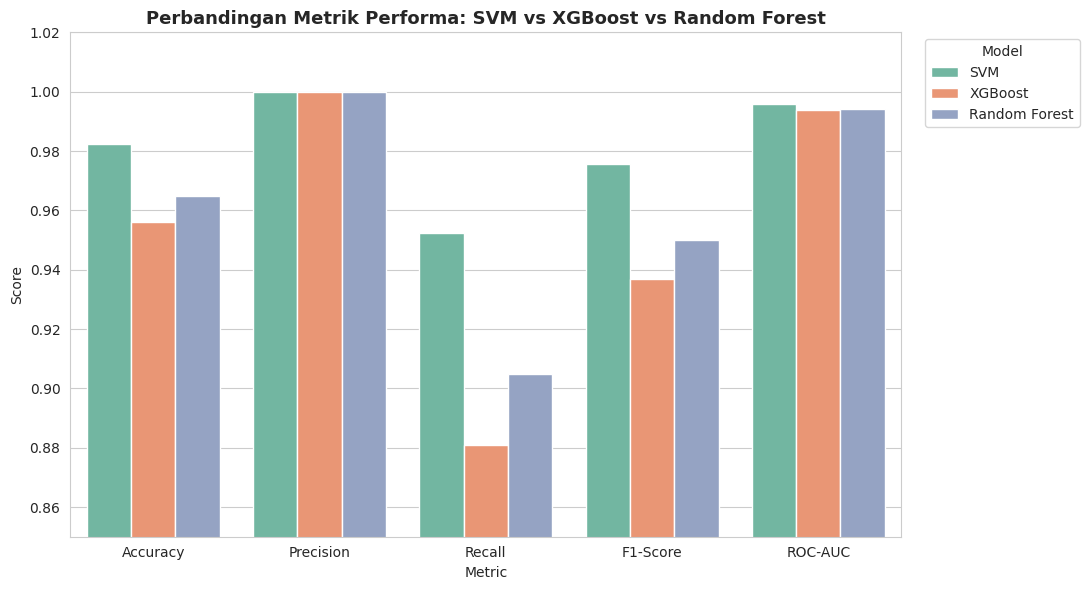

In [3]:

results_plot = results_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(11, 6))
sns.barplot(data=results_plot, x='Metric', y='Score', hue='Model', palette='Set2')
plt.ylim(0.85, 1.02)
plt.title('Perbandingan Metrik Performa: SVM vs XGBoost vs Random Forest', fontsize=13, fontweight='bold')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Kesimpulan Akhir

In [4]:

best_model_name = results_df['ROC-AUC'].idxmax()
print('=== Ringkasan Performa Model (Test Set) ===')
display(results_df.sort_values('ROC-AUC', ascending=False))
print(f"\nModel dengan performa terbaik berdasarkan ROC-AUC: {best_model_name}")


=== Ringkasan Performa Model (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
SVM,0.9825,1.0,0.9524,0.9756,0.9960
Random Forest,0.9649,1.0,0.9048,0.9500,0.9942
XGBoost,0.9561,1.0,0.8810,0.9367,0.9937



Model dengan performa terbaik berdasarkan ROC-AUC: SVM


### Kesimpulan

1. **Performa Model** — Ketiga model (SVM, XGBoost, Random Forest) mampu mengklasifikasikan diagnosis kanker payudara dengan akurasi tinggi (umumnya >95%), karena fitur citra FNA sangat diskriminatif antar kelas.
2. **Model Terbaik** — Lihat model dengan ROC-AUC tertinggi pada tabel di atas; perbedaan performa antar model umumnya tipis pada dataset ini.
3. **Interpretasi (Explainability)** — Berdasarkan SHAP & feature importance di masing-masing notebook algoritma, fitur seperti `concave points_worst`, `radius_worst`, `perimeter_worst`, `area_worst`, dan `concave points_mean` konsisten menjadi fitur paling berpengaruh — sejalan dengan pengetahuan medis bahwa bentuk/tekstur inti sel yang tidak beraturan (concavity tinggi) berasosiasi dengan keganasan tumor.
4. **Nilai Klinis** — Pendekatan *explainable AI* penting agar tenaga medis dapat memahami dasar keputusan model, bukan sekadar menerima output *black box*.

### Batasan & Saran Pengembangan
- Dataset relatif kecil (569 sampel) — validasi eksternal akan memperkuat generalisasi.
- Bisa dieksplorasi *feature selection* untuk mengurangi multikolinearitas antar fitur `_mean`, `_se`, `_worst`.
- Untuk deployment klinis nyata, diperlukan validasi lanjut bersama tenaga medis serta uji coba prospektif.
